<a href="https://colab.research.google.com/github/priyanshugupta-26/canny_edge_manually/blob/main/cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

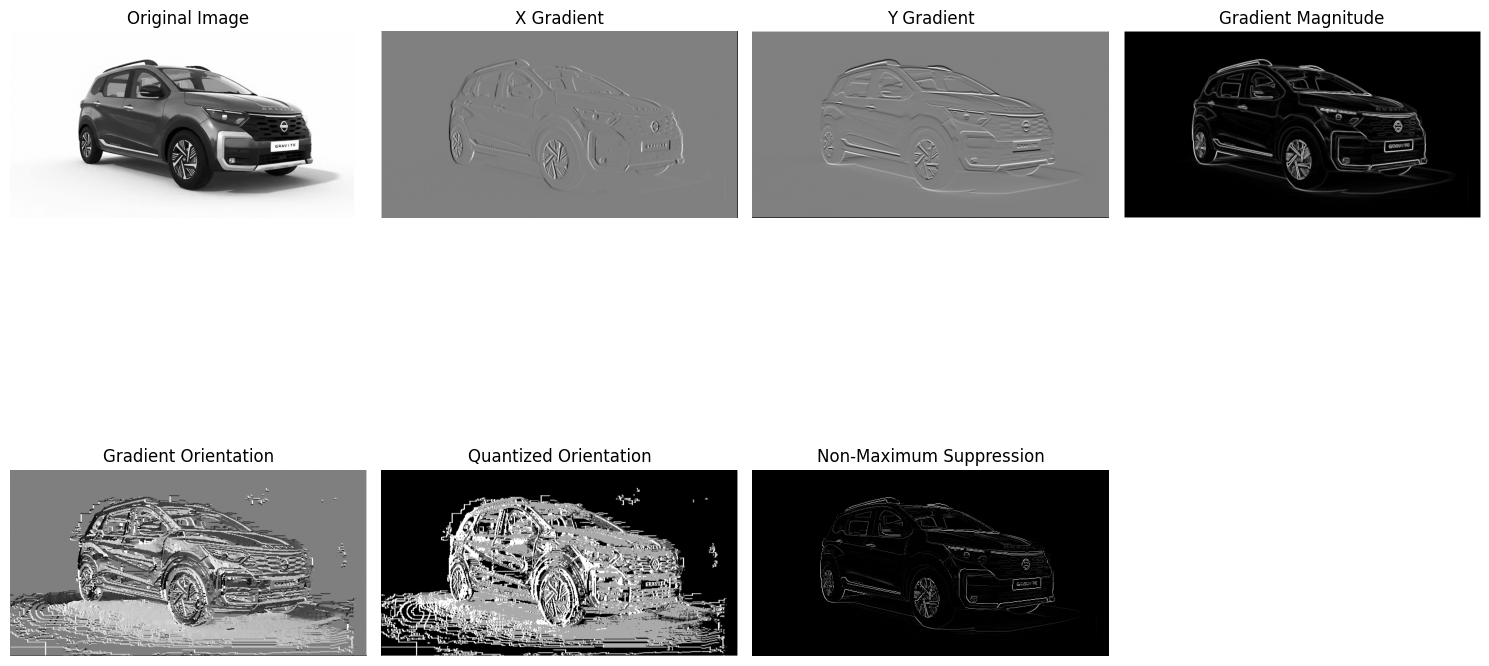

In [ ]:
def filtered_image(img, kernel, p=0, s=1):

    m = img.shape[0]
    n = img.shape[1]

    km = kernel.shape[0]
    kn = kernel.shape[1]

    rows = ((m - km + 2 * p) // s) + 1
    cols = ((n - kn + 2 * p) // s) + 1

    output = np.zeros((rows, cols))

    padded_img = np.pad(
        img,
        ((p, p), (p, p)),
        mode="constant",
        constant_values=0
    )

    for i in range(rows):
        for j in range(cols):

            region = padded_img[
                i * s:i * s + km,
                j * s:j * s + kn
            ]

            output[i, j] = np.sum(region * kernel)

    return output




Gx = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
])

Gy = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])




df_dx = filtered_image(img, Gx, p=1, s=1)

df_dy = filtered_image(img, Gy, p=1, s=1)




magnitude = np.sqrt(df_dx**2 + df_dy**2)



orientation = np.arctan2(df_dy, df_dx)

orientation = np.degrees(orientation)




def Quantize_orientation(angle_img):

    angle_img = angle_img.copy()

    for i in range(angle_img.shape[0]):
        for j in range(angle_img.shape[1]):

            angle = angle_img[i, j]

            if -22.5 <= angle < 22.5:
                angle_img[i, j] = 0

            elif 22.5 <= angle < 67.5:
                angle_img[i, j] = 45

            elif 67.5 <= angle < 112.5:
                angle_img[i, j] = 90

            elif 112.5 <= angle <= 180:
                angle_img[i, j] = 135

            elif -180 <= angle < -112.5:
                angle_img[i, j] = 135

            elif -112.5 <= angle < -67.5:
                angle_img[i, j] = 90

            elif -67.5 <= angle < -22.5:
                angle_img[i, j] = 45

    return angle_img


quantized_orientation = Quantize_orientation(orientation)



angle_set = {
    0:   [(0, -1), (0, 1)],
    180: [(0, -1), (0, 1)],

    45:  [(-1, -1), (1, 1)],
    -135: [(-1, -1), (1, 1)],

    90:  [(-1, 0), (1, 0)],
    -90: [(-1, 0), (1, 0)],

    135: [(-1, 1), (1, -1)],
    -45: [(-1, 1), (1, -1)]
}




def non_maximum_suppression(magnitude, quantized_orientation, angle_set):

    rows, cols = magnitude.shape

    nms = np.zeros((rows, cols))

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):

            angle = quantized_orientation[i, j]

            neighbours = angle_set[int(angle)]

            r1, c1 = neighbours[0]
            r2, c2 = neighbours[1]

            neighbour1 = magnitude[i + r1, j + c1]
            neighbour2 = magnitude[i + r2, j + c2]

            current = magnitude[i, j]


            if current >= neighbour1 and current >= neighbour2:
                nms[i, j] = current
            else:
                nms[i, j] = 0

    return nms




nms_result = non_maximum_suppression(
    magnitude,
    quantized_orientation,
    angle_set
)




plt.figure(figsize=(15, 10))


plt.subplot(2, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")


plt.subplot(2, 4, 2)
plt.imshow(df_dx, cmap="gray")
plt.title("X Gradient")
plt.axis("off")


plt.subplot(2, 4, 3)
plt.imshow(df_dy, cmap="gray")
plt.title("Y Gradient")
plt.axis("off")


plt.subplot(2, 4, 4)
plt.imshow(magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")


plt.subplot(2, 4, 5)
plt.imshow(orientation, cmap="gray")
plt.title("Gradient Orientation")
plt.axis("off")


plt.subplot(2, 4, 6)
plt.imshow(quantized_orientation, cmap="gray")
plt.title("Quantized Orientation")
plt.axis("off")


plt.subplot(2, 4, 7)
plt.imshow(nms_result, cmap="gray")
plt.title("Non-Maximum Suppression")
plt.axis("off")


plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# =========================================================
# 1. LOAD IMAGE
# =========================================================

image_path = "/content/gravite-exterior-right-front-three-quarter-6.avif"

img = Image.open(image_path).convert("L")
img = np.array(img)

print("Image type:", type(img))
print("Image dtype:", img.dtype)
print("Image shape:", img.shape)


# =========================================================
# 2. IMAGE FILTERING
# =========================================================

def filtered_image(img, kernel, p=0, s=1):

    m = img.shape[0]
    n = img.shape[1]

    km = kernel.shape[0]
    kn = kernel.shape[1]

    rows = ((m - km + 2 * p) // s) + 1
    cols = ((n - kn + 2 * p) // s) + 1

    output = np.zeros((rows, cols))

    padded_img = np.pad(
        img,
        ((p, p), (p, p)),
        mode="constant",
        constant_values=0
    )

    for i in range(rows):
        for j in range(cols):

            region = padded_img[
                i * s:i * s + km,
                j * s:j * s + kn
            ]

            output[i, j] = np.sum(region * kernel)

    return output


# =========================================================
# 3. SOBEL KERNELS
# =========================================================

Gx = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
])

Gy = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])


# =========================================================
# 4. X AND Y GRADIENT
# =========================================================

df_dx = filtered_image(img, Gx, p=1, s=1)
df_dy = filtered_image(img, Gy, p=1, s=1)


# =========================================================
# 5. GRADIENT MAGNITUDE
# =========================================================

magnitude = np.sqrt(df_dx**2 + df_dy**2)


# =========================================================
# 6. GRADIENT ORIENTATION
# =========================================================

orientation = np.arctan2(df_dy, df_dx)

orientation = np.degrees(orientation)


# =========================================================
# 7. QUANTIZATION OF ORIENTATION
# =========================================================

def Quantize_orientation(angle_img):

    angle_img = angle_img.copy()

    for i in range(angle_img.shape[0]):
        for j in range(angle_img.shape[1]):

            angle = angle_img[i, j]

            if -22.5 <= angle < 22.5:
                angle_img[i, j] = 0

            elif 22.5 <= angle < 67.5:
                angle_img[i, j] = 45

            elif 67.5 <= angle < 112.5:
                angle_img[i, j] = 90

            elif 112.5 <= angle <= 180:
                angle_img[i, j] = 135

            elif -180 <= angle < -112.5:
                angle_img[i, j] = 135

            elif -112.5 <= angle < -67.5:
                angle_img[i, j] = 90

            elif -67.5 <= angle < -22.5:
                angle_img[i, j] = 45

    return angle_img


quantized_orientation = Quantize_orientation(orientation)


# =========================================================
# 8. ANGLE SET
# According to sir's board
# =========================================================

angle_set = {

    # 0 degree and 180 degree
    0: [
        (0, -1),
        (0, 1)
    ],

    180: [
        (0, -1),
        (0, 1)
    ],

    # 45 degree and -135 degree
    45: [
        (1, -1),
        (-1, 1)
    ],

    -135: [
        (1, -1),
        (-1, 1)
    ],

    # 90 degree and -90 degree
    90: [
        (-1, 0),
        (1, 0)
    ],

    -90: [
        (-1, 0),
        (1, 0)
    ],

    # 135 degree and -45 degree
    135: [
        (-1, -1),
        (1, 1)
    ],

    -45: [
        (-1, -1),
        (1, 1)
    ]
}


# =========================================================
# 9. NON-MAXIMUM SUPPRESSION
# =========================================================

def non_maximum_suppression(
        magnitude,
        quantized_orientation,
        angle_set):

    rows, cols = magnitude.shape

    nms = np.zeros((rows, cols))

    for i in range(1, rows - 1):

        for j in range(1, cols - 1):

            angle = quantized_orientation[i, j]

            neighbours = angle_set[int(angle)]

            r1, c1 = neighbours[0]
            r2, c2 = neighbours[1]

            neighbour1 = magnitude[
                i + r1,
                j + c1
            ]

            neighbour2 = magnitude[
                i + r2,
                j + c2
            ]

            current = magnitude[i, j]

            if current >= neighbour1 and current >= neighbour2:
                nms[i, j] = current

            else:
                nms[i, j] = 0

    return nms


nms_result = non_maximum_suppression(
    magnitude,
    quantized_orientation,
    angle_set
)


# =========================================================
# 10. HYSTERESIS THRESHOLDING
# =========================================================

def hyst_thr(gradient, T_low, T_high):

    strong_edge = gradient > T_high

    weak_edge = (
        (gradient >= T_low) &
        (gradient <= T_high)
    )

    return strong_edge, weak_edge


# ---------------------------------------------------------
# Choose thresholds
# ---------------------------------------------------------

T_high = 100
T_low = 50


strong_edge, weak_edge = hyst_thr(
    nms_result,
    T_low,
    T_high
)


# =========================================================
# 11. EDGE LINKING
# =========================================================

def edge_linking(strong_edge, weak_edge):

    rows, cols = strong_edge.shape

    final_edge = strong_edge.copy()

    # 8-neighbourhood
    neighbourhood = [
        (-1, -1),
        (-1,  0),
        (-1,  1),
        ( 0, -1),
        ( 0,  1),
        ( 1, -1),
        ( 1,  0),
        ( 1,  1)
    ]

    changed = True

    while changed:

        changed = False

        for i in range(1, rows - 1):

            for j in range(1, cols - 1):

                # If pixel is a weak edge
                if weak_edge[i, j] and not final_edge[i, j]:

                    for di, dj in neighbourhood:

                        ni = i + di
                        nj = j + dj

                        # If weak edge is connected
                        # to a strong edge
                        if final_edge[ni, nj]:

                            final_edge[i, j] = True

                            changed = True

                            break

    return final_edge


final_edge = edge_linking(
    strong_edge,
    weak_edge
)


# =========================================================
# 12. CONVERT FINAL EDGE TO IMAGE
# =========================================================

final_edge = final_edge.astype(np.uint8) * 255


# =========================================================
# DISPLAY RESULTS
# =========================================================

plt.figure(figsize=(15, 12))


plt.subplot(3, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")


plt.subplot(3, 4, 2)
plt.imshow(df_dx, cmap="gray")
plt.title("X Gradient")
plt.axis("off")


plt.subplot(3, 4, 3)
plt.imshow(df_dy, cmap="gray")
plt.title("Y Gradient")
plt.axis("off")


plt.subplot(3, 4, 4)
plt.imshow(magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")


plt.subplot(3, 4, 5)
plt.imshow(orientation, cmap="gray")
plt.title("Gradient Orientation")
plt.axis("off")


plt.subplot(3, 4, 6)
plt.imshow(quantized_orientation, cmap="gray")
plt.title("Quantized Orientation")
plt.axis("off")


plt.subplot(3, 4, 7)
plt.imshow(nms_result, cmap="gray")
plt.title("Non-Maximum Suppression")
plt.axis("off")


plt.subplot(3, 4, 8)
plt.imshow(strong_edge, cmap="gray")
plt.title("Strong Edges")
plt.axis("off")


plt.subplot(3, 4, 9)
plt.imshow(weak_edge, cmap="gray")
plt.title("Weak Edges")
plt.axis("off")


plt.subplot(3, 4, 10)
plt.imshow(
    strong_edge | weak_edge,
    cmap="gray"
)
plt.title("Strong + Weak Edges")
plt.axis("off")


plt.subplot(3, 4, 11)
plt.imshow(final_edge, cmap="gray")
plt.title("Final Canny Edge")
plt.axis("off")


plt.tight_layout()
plt.show()





